In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from IPython.display import display

import matplotlib.pyplot as plt
import os

In [2]:
# put all the joined data frames into a dictionary for easy access

joined_dfs = {}

for year in range(2014, 2025):
    df = pd.read_csv(f'../Data/raw_data/{year}/join_df_{year}.csv')
    joined_dfs[year] = df

### Each joined_df is the result of joining Institutional HR, Finance and Header Information

In [3]:
joined_dfs[2014].head()

,UNITID,INSTNM,ADDR,CITY,STABBR,ZIP,FIPS,OBEREG,CHFNM,CHFTITLE,...,EF_UNDERGRAD,EF_GRADUATE,RET_PCF,RET_PCP,STUFACR,EAP_INST_TOTAL,EAP_INST_PT,EAP_INST_TENURED,EAP_INST_TENURETRACK,EAP_INST_NOTRACK
0,100654,Alabama A & M University,4900 Meridian Street,Normal,AL,35762,1,5,"Dr. Andrew Hugine, Jr.",President,...,4210.0,1123.0,66.0,33.0,20.0,256.0,13.0,110.0,47.0,99.0
1,100663,University of Alabama at Birmingham,Administration Bldg Suite 1070,Birmingham,AL,35294-0110,1,5,Ray L. Watts,President,...,11679.0,7019.0,83.0,58.0,18.0,2392.0,182.0,804.0,490.0,1098.0
2,100706,University of Alabama in Huntsville,301 Sparkman Dr,Huntsville,AL,35899,1,5,Robert A. Altenkirch,President,...,5618.0,1730.0,77.0,62.0,16.0,479.0,181.0,135.0,82.0,262.0
3,100724,Alabama State University,915 S Jackson Street,Montgomery,AL,36104-0271,1,5,Gwen Boyd,President,...,4812.0,707.0,57.0,28.0,16.0,428.0,159.0,114.0,63.0,236.0
4,100751,The University of Alabama,739 University Blvd,Tuscaloosa,AL,35487-0166,1,5,Dr. Judith L. Bonner,President,...,30752.0,5295.0,87.0,60.0,21.0,1847.0,560.0,590.0,238.0,1019.0


### Overall summary across all years

In [4]:
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# Overall summary across all years
summary_rows = []
for year, df in joined_dfs.items():
    summary_rows.append({
        "year": year,
        "rows": df.shape[0],
        "columns": df.shape[1],
        "numeric_cols": df.select_dtypes(include=["number"]).shape[1],
        "categorical_cols": df.select_dtypes(exclude=["number"]).shape[1],
        "missing_cells": int(df.isna().sum().sum()),
        "duplicate_rows": int(df.duplicated().sum()),
    })

summary_df = pd.DataFrame(summary_rows).sort_values("year")
display(summary_df)

,year,rows,columns,numeric_cols,categorical_cols,missing_cells,duplicate_rows
0,2014,725,427,248,179,28843,0
1,2015,734,437,254,183,30581,0
2,2016,759,327,199,128,25465,0
3,2017,775,327,198,129,26970,0
4,2018,796,328,198,130,30789,0
5,2019,807,336,202,134,32274,0
6,2020,806,397,234,163,34540,0
7,2021,784,393,223,170,13816,0
8,2022,814,392,222,170,20854,0
9,2023,822,392,230,162,21342,0


### EDA per Year

In [5]:
# Per-year EDA
for year, df in joined_dfs.items():
    print(f"\n{'=' * 70}")
    print(f"EDA for {year}")
    print(f"Shape: {df.shape}")
    print("Data types:")
    print(df.dtypes.astype(str))

    # Missing values
    missing = df.isna().sum().sort_values(ascending=False)
    missing = missing[missing > 0]
    if not missing.empty:
        print("\nMissing values (top 10 columns):")
        display(missing.head(10))

    # Numeric summary and histograms
    num_cols = df.select_dtypes(include=["number"]).columns.tolist()
    if num_cols:
        print("\nNumeric column summary:")
        display(df[num_cols].describe().T)

    # Categorical value counts
    cat_cols = df.select_dtypes(exclude=["number"]).columns.tolist()
    if cat_cols:
        print("\nTop values for categorical columns:")
        for col in cat_cols[:5]:
            counts = df[col].value_counts(dropna=False).head(10)
            if not counts.empty:
                print(f"\n{col}:")
                print(counts)


EDA for 2014
Shape: (725, 427)
Data types:
UNITID                    int64
INSTNM                   object
ADDR                     object
CITY                     object
STABBR                   object
                         ...   
EAP_INST_TOTAL          float64
EAP_INST_PT             float64
EAP_INST_TENURED        float64
EAP_INST_TENURETRACK    float64
EAP_INST_NOTRACK        float64
Length: 427, dtype: object

Missing values (top 10 columns):


SALASST     725
SFTEOTHR    725
SALTOTL     725
SALPROF     725
SALASSC     725
SALINST     725
SALLECT     725
SALNRNK     725
SFTEPSTC    725
SFTELCAI    725
dtype: int64


Numeric column summary:


,count,mean,std,min,25%,50%,75%,max
UNITID,725.0,1.965031e+05,6.989169e+04,100654.0,1.550250e+05,196033.0,2.208620e+05,484905.0
FIPS,725.0,3.106759e+01,1.663484e+01,1.0,1.700000e+01,34.0,4.200000e+01,78.0
OBEREG,725.0,4.507586e+00,2.171897e+00,0.0,3.000000e+00,5.0,6.000000e+00,9.0
EIN,725.0,5.151423e+08,2.601507e+08,-1.0,3.164021e+08,556000822.0,7.260008e+08,996000354.0
OPEID,725.0,4.415575e+05,6.033862e+05,-2.0,1.949000e+05,295000.0,3.698000e+05,4229500.0
...,...,...,...,...,...,...,...,...
EAP_INST_TOTAL,716.0,7.679078e+02,8.402197e+02,1.0,2.260000e+02,462.0,1.043750e+03,7504.0
EAP_INST_PT,716.0,2.692235e+02,3.025622e+02,0.0,7.575000e+01,165.5,3.512500e+02,2435.0
EAP_INST_TENURED,686.0,2.614942e+02,3.095466e+02,6.0,6.625000e+01,153.0,3.337500e+02,2224.0
EAP_INST_TENURETRACK,680.0,9.955000e+01,1.112456e+02,1.0,3.100000e+01,66.5,1.290000e+02,1557.0



Top values for categorical columns:

INSTNM:
INSTNM
Alabama A & M University                                            1
California University of Pennsylvania                               1
Clarion University of Pennsylvania                                  1
The Dickinson School of Law of the Pennsylvania State University    1
East Stroudsburg University of Pennsylvania                         1
Edinboro University of Pennsylvania                                 1
Indiana University of Pennsylvania-Main Campus                      1
Kutztown University of Pennsylvania                                 1
The Lincoln University                                              1
Lock Haven University                                               1
Name: count, dtype: int64

ADDR:
ADDR
                        5
One University Plaza    2
One University Place    2
300 Campus Drive        2
1 University Circle     2
1 Main Street           2
4900 Meridian Street    1
15200 Kutztown Rd       1
8

...


Top values for categorical columns:

INSTNM:
INSTNM
Lincoln University                                            2
Alabama A & M University                                      1
University of Pittsburgh-Bradford                             1
Pennsylvania State University-Penn State Brandywine           1
Pennsylvania State University-Penn State DuBois               1
Pennsylvania State University-Penn State Fayette- Eberly      1
Pennsylvania State University-Penn State Hazleton             1
Pennsylvania State University-Main Campus                     1
Pennsylvania State University-Penn State Greater Allegheny    1
Pennsylvania State University-Penn State Mont Alto            1
Name: count, dtype: int64

IALIAS:
IALIAS
NaN        353
WSU          3
BC           3
ECU          2
Western      2
GHC          2
MSU          2
ISU          2
NSU          2
K-State      2
Name: count, dtype: int64

ADDR:
ADDR
NaN                     4
One University Drive    2
One University Plaza    2

SALNRNK        542
SALLECT        444
IALIAS         368
ATHURL         351
F1M07          291
F1M05          291
F1M08          291
F1M06          291
EF_GRADUATE    270
F1M04          261
dtype: int64


Numeric column summary:


,count,mean,std,min,25%,50%,75%,max
UNITID,848.0,1.993884e+05,7.706048e+04,1.006540e+05,1.513195e+05,1.961535e+05,2.265075e+05,4.985710e+05
FIPS,848.0,3.112028e+01,1.726793e+01,1.000000e+00,1.300000e+01,3.500000e+01,4.500000e+01,7.800000e+01
OBEREG,848.0,4.810142e+00,2.209893e+00,0.000000e+00,3.000000e+00,5.000000e+00,6.000000e+00,9.000000e+00
GENTELE,848.0,1.388826e+12,1.121376e+13,2.012002e+09,4.025581e+09,6.071098e+09,8.072296e+09,2.078348e+14
EIN,848.0,5.523155e+08,2.620947e+08,3.414000e+06,3.560017e+08,5.809527e+08,7.511806e+08,9.960004e+08
...,...,...,...,...,...,...,...,...
EF_UNDERGRAD,833.0,9.924239e+03,1.101948e+04,2.100000e+01,2.577000e+03,6.006000e+03,1.266600e+04,7.307700e+04
EF_GRADUATE,578.0,2.838007e+03,3.687513e+03,1.000000e+00,5.375000e+02,1.573500e+03,3.514250e+03,3.277200e+04
RET_PCF,650.0,7.457077e+01,1.273320e+01,0.000000e+00,6.800000e+01,7.600000e+01,8.200000e+01,1.000000e+02
RET_PCP,606.0,4.616997e+01,2.294368e+01,0.000000e+00,3.200000e+01,4.600000e+01,6.100000e+01,1.000000e+02



Top values for categorical columns:

INSTNM:
INSTNM
Lincoln University                                          2
Alabama A & M University                                    1
Pennsylvania State University-Penn State Beaver             1
Pennsylvania State University-Penn State Berks              1
Pennsylvania State University-Penn State Harrisburg         1
Pennsylvania State University-Penn State Brandywine         1
Pennsylvania State University-Penn State DuBois             1
Pennsylvania State University-Penn State Fayette- Eberly    1
Pennsylvania State University-Penn State Hazleton           1
Pennsylvania State University-Main Campus                   1
Name: count, dtype: int64

IALIAS:
IALIAS
NaN        368
WSU          3
BC           3
MSU          2
GHC          2
ECU          2
K-State      2
NSU          2
Western      2
HCC          2
Name: count, dtype: int64

ADDR:
ADDR
NaN                     5
One University Drive    2
1 University Circle     2
300 Campus Drive   

### Check for repeated information in each yearly joined dataframe

In [6]:
dup_summary = []

for year, df in joined_dfs.items():
    # Exact duplicate rows across all columns
    row_dup_count = int(df.duplicated().sum())

    # Duplicate UNITID values
    unitid_dup_count = 0
    if "UNITID" in df.columns:
        unitid_series = df["UNITID"].dropna()
        unitid_dup_count = int(unitid_series.duplicated().sum()) if not unitid_series.empty else 0

    # Duplicate column names
    col_dup_count = int(df.columns.duplicated().sum())

    dup_summary.append({
        "year": year,
        "duplicate_rows": row_dup_count,
        "duplicate_UNITID_values": unitid_dup_count,
        "duplicate_column_names": col_dup_count,
    })

dup_summary_df = pd.DataFrame(dup_summary).sort_values("year")
display(dup_summary_df)

# Print any duplicated rows if present
for year, df in joined_dfs.items():
    dup_rows = df[df.duplicated(keep=False)]
    if not dup_rows.empty:
        print(f"\nRepeated rows found for {year}:")
        display(dup_rows.head(10))

# Final summary message
if (dup_summary_df["duplicate_rows"] > 0).any() or (dup_summary_df["duplicate_UNITID_values"] > 0).any() or (dup_summary_df["duplicate_column_names"] > 0).any():
    print("\nRepeated information was found in at least one year.")
else:
    print("\nNo repeated information was found in any year.")

,year,duplicate_rows,duplicate_UNITID_values,duplicate_column_names
0,2014,0,0,0
1,2015,0,0,0
2,2016,0,0,0
3,2017,0,0,0
4,2018,0,0,0
5,2019,0,0,0
6,2020,0,0,0
7,2021,0,0,0
8,2022,0,0,0
9,2023,0,0,0



No repeated information was found in any year.


### Reloaded the dasets and added a year feature. 

In [7]:
joined_dfs = []

# ---------------------------------------------------------
# 1. LOAD AND STACK ALL YEARLY DATA (2014-2024)
# ---------------------------------------------------------
for year in range(2014, 2025):
    file_path = f'../Data/raw_data/{year}/join_df_{year}.csv'
    
    if os.path.exists(file_path):
        # Load the data for the specific year
        df = pd.read_csv(file_path)
        
        # Add a 'YEAR' column to track the timeline
        df['YEAR'] = year
        
        joined_dfs.append(df)
        print(f"[+] Successfully loaded data for {year} (Rows: {len(df)})")
    else:
        print(f"[-] File for {year} not found. Skipping...")

# Concatenate all the dataframes vertically into one master dataframe
master_panel_df = pd.concat(joined_dfs, ignore_index=True)
print(f"\n[+] Master Panel Created. Total Rows: {len(master_panel_df)}")

[+] Successfully loaded data for 2014 (Rows: 725)
[+] Successfully loaded data for 2015 (Rows: 734)
[+] Successfully loaded data for 2016 (Rows: 759)
[+] Successfully loaded data for 2017 (Rows: 775)
[+] Successfully loaded data for 2018 (Rows: 796)
[+] Successfully loaded data for 2019 (Rows: 807)
[+] Successfully loaded data for 2020 (Rows: 806)
[+] Successfully loaded data for 2021 (Rows: 784)
[+] Successfully loaded data for 2022 (Rows: 814)
[+] Successfully loaded data for 2023 (Rows: 822)
[+] Successfully loaded data for 2024 (Rows: 848)

[+] Master Panel Created. Total Rows: 8670


### Feature Engineering binary target feature (AI-Assisted)

In [8]:
STAFF_COL = 'SFTEINST'
MIN_BASE  = 1.0
HORIZON   = 2   # years ahead: 2 = predict a cut over t -> t+2 (the 18-24 month framing)

# one row per institution-year, in chronological order (guards against the stale-df/dup issues)
master_panel_df = (master_panel_df
                   .drop_duplicates(['UNITID', 'YEAR'])
                   .sort_values(['UNITID', 'YEAR'])
                   .reset_index(drop=True)
                   .copy())
g = master_panel_df.groupby('UNITID')

def forward_pct(col, horizon=HORIZON):
    """Forward % change (t -> t+horizon), valid only across a gap-free window with a usable base."""
    cur = master_panel_df[col]
    nxt = g[col].shift(-horizon)
    nyr = g['YEAR'].shift(-horizon)
    valid = (nyr - master_panel_df['YEAR']).eq(horizon) & cur.notna() & nxt.notna() & cur.ge(MIN_BASE)
    return ((nxt - cur) / cur * 100).where(valid), valid

pct_inst, valid_inst = forward_pct(STAFF_COL)      # instructional FTE, over 2 years
pct_totl, valid_totl = forward_pct('SFTETOTL')     # total FTE staff, over 2 years

master_panel_df = master_panel_df.assign(
    FTE_INST_PCT_CHANGE_2Y     = pct_inst,
    FTE_TOTL_PCT_CHANGE_2Y     = pct_totl,
    TARGET_STAFF_CUT           = (pct_inst <= -5).where(valid_inst).astype('Int64'),   # instructional: >=5% drop over 2 yrs
    TARGET_VULNERABLE_TOTAL    = (pct_totl < 0).where(valid_totl).astype('Int64'),     # total: any decline over 2 yrs
)

# ---------- review ----------
for t in ['TARGET_STAFF_CUT', 'TARGET_VULNERABLE_TOTAL']:
    lab = master_panel_df[t].notna()
    print(f"{t}: labeled={int(lab.sum())} of {len(master_panel_df)}, "
          f"positives={int(master_panel_df[t].sum())}, "
          f"rate={master_panel_df.loc[lab, t].mean() * 100:.1f}%")

print(master_panel_df[['UNITID', 'YEAR', STAFF_COL, 'FTE_INST_PCT_CHANGE_2Y', 'TARGET_STAFF_CUT']]
      .head(10).to_string(index=False))

# master_panel_df.to_csv('master_panel_df.csv', index=False)   # uncomment to save

TARGET_STAFF_CUT: labeled=6711 of 8670, positives=1646, rate=24.5%
TARGET_VULNERABLE_TOTAL: labeled=6725 of 8670, positives=3092, rate=46.0%
 UNITID  YEAR  SFTEINST  FTE_INST_PCT_CHANGE_2Y  TARGET_STAFF_CUT
 100654  2014     247.0               16.599190                 0
 100654  2015     279.0                4.659498                 0
 100654  2016     288.0                1.041667                 0
 100654  2017     292.0               -4.452055                 0
 100654  2018     291.0               -0.343643                 0
 100654  2019     279.0              -13.978495                 1
 100654  2020     290.0                1.724138                 0
 100654  2021     240.0               26.666667                 0
 100654  2022     295.0                8.023729                 0
 100654  2023     304.0                     NaN              <NA>


### Initial overview (ALL YEARS COMBINED)

In [9]:
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# 1) Basic overview
print("Shape of master_panel_df:", master_panel_df.shape)
display(master_panel_df.head(3))

Shape of master_panel_df: (8670, 551)


,UNITID,INSTNM,ADDR,CITY,STABBR,ZIP,FIPS,OBEREG,CHFNM,CHFTITLE,...,CARNEGIESAEC,CARNEGIERSCH,CARNEGIESIZE,CARNEGIEALF,CARNEGIEAPM,CARNEGIEGPM,FTE_INST_PCT_CHANGE_2Y,FTE_TOTL_PCT_CHANGE_2Y,TARGET_STAFF_CUT,TARGET_VULNERABLE_TOTAL
0,100654,Alabama A & M University,4900 Meridian Street,Normal,AL,35762,1,5,"Dr. Andrew Hugine, Jr.",President,...,NaN,NaN,NaN,NaN,NaN,NaN,16.599190,6.549118,0,0
1,100654,Alabama A & M University,4900 Meridian Street,Normal,AL,35762,1,5,"Dr. Andrew Hugine, Jr.",President,...,NaN,NaN,NaN,NaN,NaN,NaN,4.659498,3.485577,0,0
2,100654,Alabama A & M University,4900 Meridian Street,Normal,AL,35762,1,5,"Dr. Andrew Hugine, Jr.",President,...,NaN,NaN,NaN,NaN,NaN,NaN,1.041667,1.063830,0,0


In [10]:
numeric_cols = master_panel_df.select_dtypes(include=["number"]).columns.tolist()
cat_cols = master_panel_df.select_dtypes(exclude=["number"]).columns.tolist()
print(f"Numeric columns: {len(numeric_cols)}")
print(f"Categorical/object columns: {len(cat_cols)}")

Numeric columns: 317
Categorical/object columns: 234


### Top columns missing values


Top missing columns:


CCIPUG          7945
CCENRPRF        7945
CCSIZSET        7945
CCUGPROF        7945
CCIPGRAD        7945
CARNEGIEAPM     7822
CARNEGIEALF     7822
CARNEGIESIZE    7822
CARNEGIERSCH    7822
CARNEGIESAEC    7822
dtype: int64

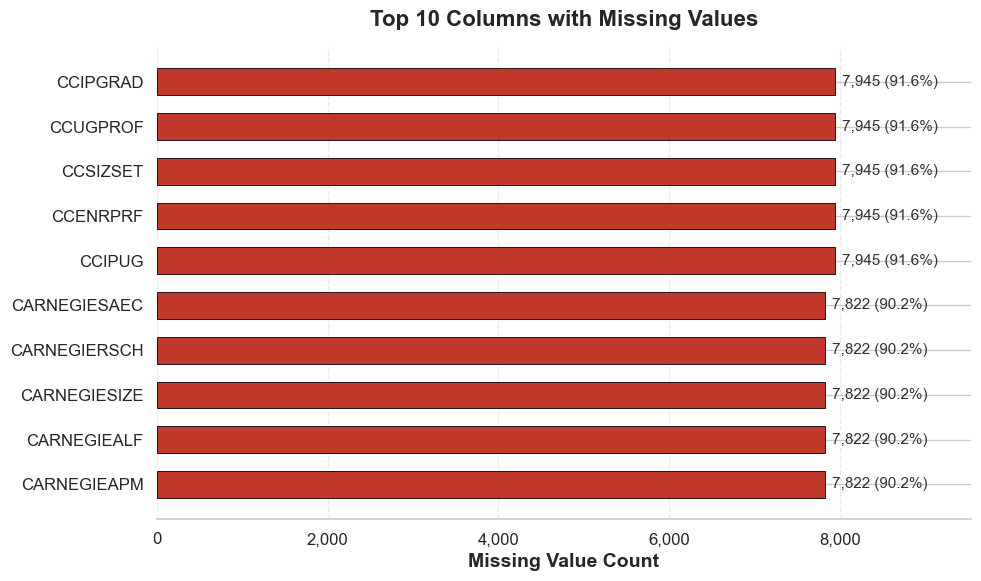

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

missing_summary = master_panel_df.isna().sum().sort_values(ascending=False)
missing_summary = missing_summary[missing_summary > 0]
missing_pct = (missing_summary / len(master_panel_df)) * 100

print("\nTop missing columns:")
display(missing_summary.head(10))

plt.rcParams.update({
    "font.size": 13,
    "axes.titlesize": 16,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
})

top_n = missing_summary.head(10).sort_values(ascending=True)  # largest bar on top
top_n_pct = missing_pct.loc[top_n.index]

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(
    top_n.index,
    top_n.values,
    color="#C0392B",
    edgecolor="black",
    linewidth=0.6,
    height=0.6
)

for bar, count, pct in zip(bars, top_n.values, top_n_pct.values):
    ax.text(
        bar.get_width() + (top_n.values.max() * 0.01),
        bar.get_y() + bar.get_height() / 2,
        f"{count:,} ({pct:.1f}%)",
        va="center",
        ha="left",
        fontsize=11,
        color="#333333"
    )

ax.set_title("Top 10 Columns with Missing Values", fontweight="bold", pad=15)
ax.set_xlabel("Missing Value Count", fontweight="bold")
ax.set_ylabel("")

ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.set_xlim(0, top_n.values.max() * 1.2)

ax.grid(axis="x", linestyle="--", alpha=0.4)
ax.set_axisbelow(True)
for spine in ["top", "right", "left"]:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.savefig("missing_values_top10.png", dpi=300, bbox_inches="tight")
plt.show()

### Records per year

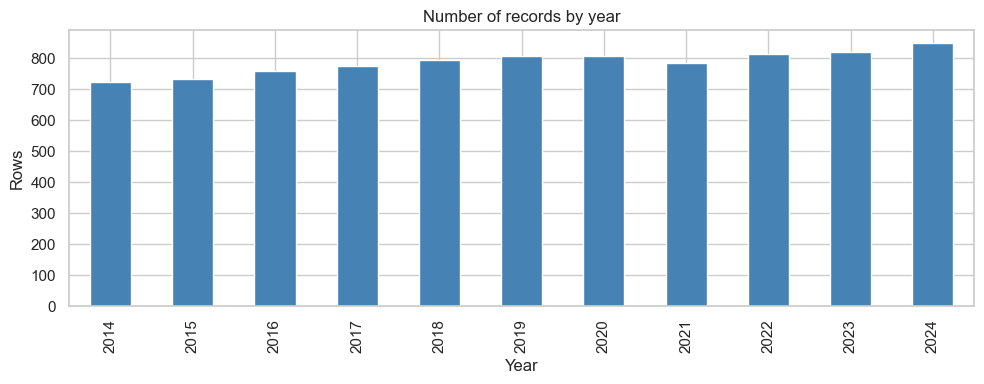

In [12]:
year_counts = master_panel_df["YEAR"].value_counts().sort_index()
plt.figure(figsize=(10, 4))
year_counts.plot(kind="bar", color="steelblue")
plt.title("Number of records by year")
plt.xlabel("Year")
plt.ylabel("Rows")
plt.tight_layout()
plt.show()

### Target Feature

/var/folders/jh/9ry3rwr171745zlhrlbbzww80000gn/T/ipykernel_24352/2916971314.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=master_panel_df, x="TARGET_VULNERABLE_TOTAL", palette="Set2")


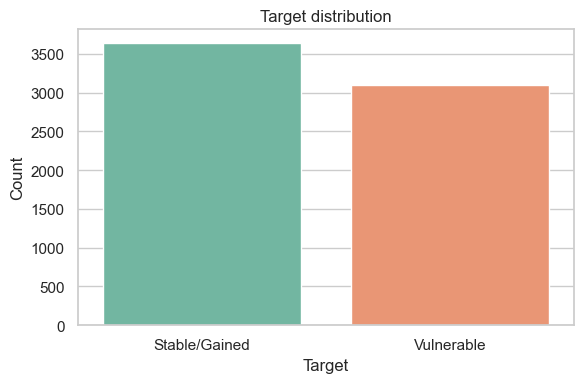

In [13]:
target_counts = master_panel_df["TARGET_VULNERABLE_TOTAL"].value_counts().sort_index()
target_labels = {0: "Stable/Gained", 1: "Vulnerable"}
plt.figure(figsize=(6, 4))
sns.countplot(data=master_panel_df, x="TARGET_VULNERABLE_TOTAL", palette="Set2")
plt.xticks(ticks=[0, 1], labels=[target_labels.get(0, "Stable/Gained"), target_labels.get(1, "Vulnerable")])
plt.title("Target distribution")
plt.xlabel("Target")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

### Some Staffing Columns

In [14]:
staff_cols = [c for c in ["SFTETOTL", "SALTOTL", "SFTEINST", "SFTEPSTC", "SFTESRVC", "SALPROF", "SALASSC"] if c in master_panel_df.columns]
print("\nStaffing columns used for EDA:", staff_cols)

display(master_panel_df[staff_cols].describe().T)


Staffing columns used for EDA: ['SFTETOTL', 'SALTOTL', 'SFTEINST', 'SFTEPSTC', 'SFTESRVC', 'SALPROF', 'SALASSC']


,count,mean,std,min,25%,50%,75%,max
SFTETOTL,8514.0,1945.374009,3186.009184,0.0,384.0,825.00,1883.50,35878.68
SFTEINST,8503.0,592.690844,767.580577,0.0,150.0,327.00,720.00,7851.33
SFTEPSTC,3250.0,682.498803,1047.930434,0.0,145.0,317.67,736.75,8786.67
SFTESRVC,8350.0,154.212231,279.256595,0.0,27.0,64.00,155.00,3985.33


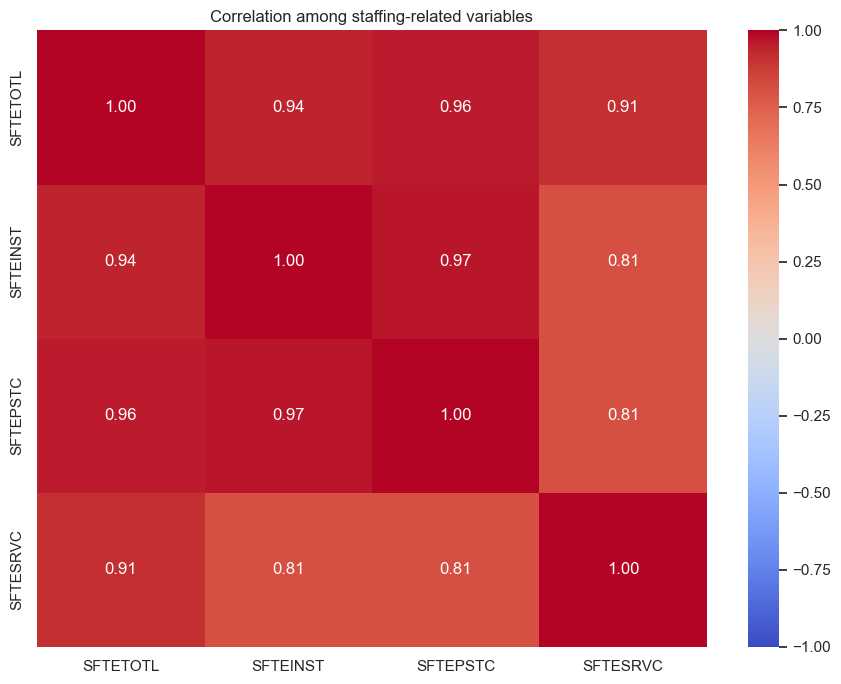

In [15]:
corr = master_panel_df[staff_cols].corr(numeric_only=True)
plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation among staffing-related variables")
plt.tight_layout()
plt.show()

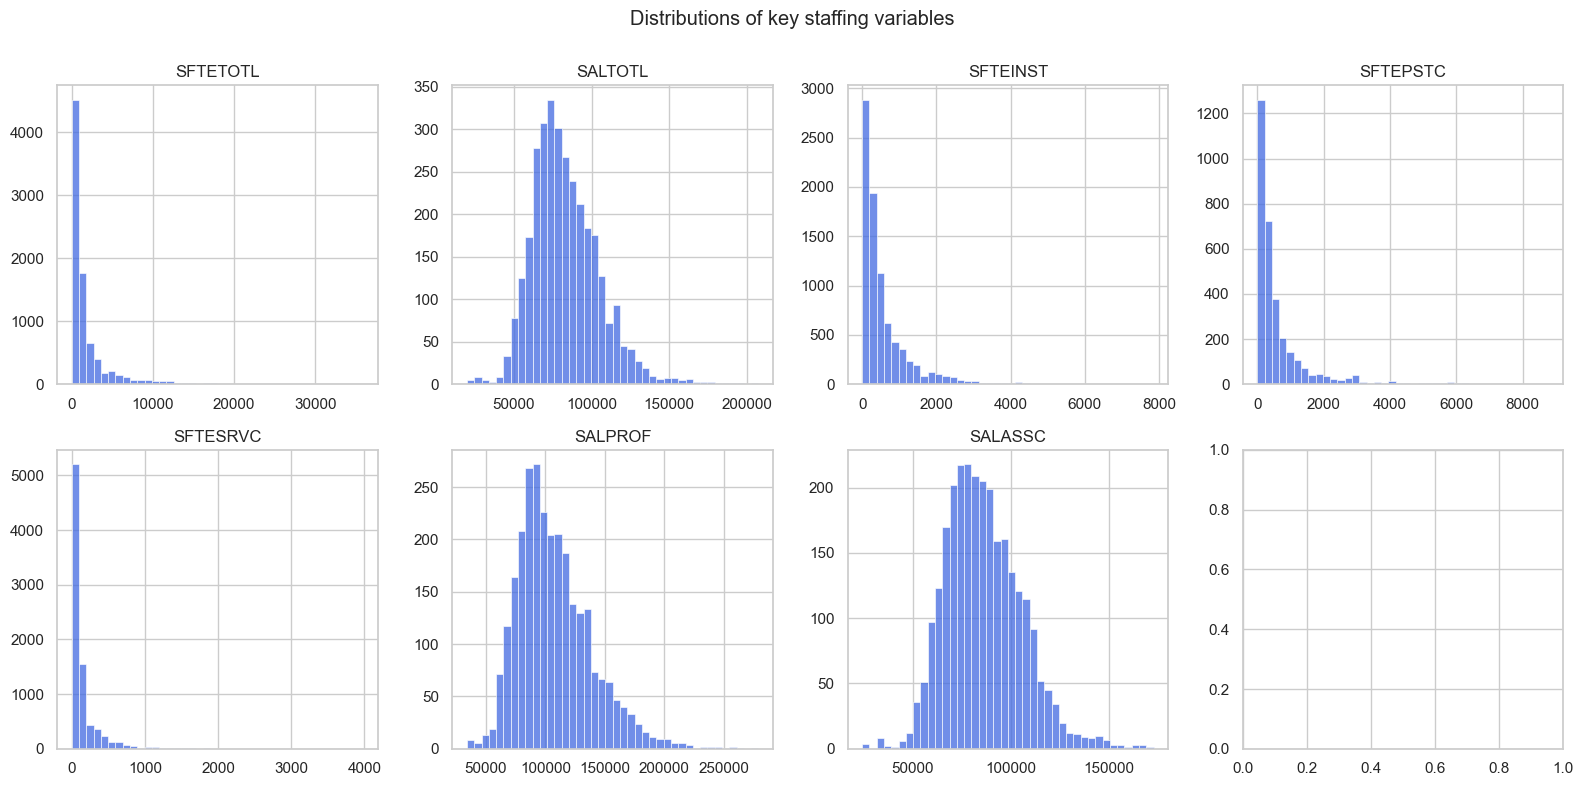

In [16]:
# 9) Distribution of staffing variables
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, col in zip(axes.flat, staff_cols):
    values = pd.to_numeric(master_panel_df[col], errors="coerce").dropna()
    sns.histplot(values, bins=40, ax=ax, color="royalblue")
    ax.set_title(col)
    ax.set_xlabel("")
    ax.set_ylabel("")
fig.suptitle("Distributions of key staffing variables")
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

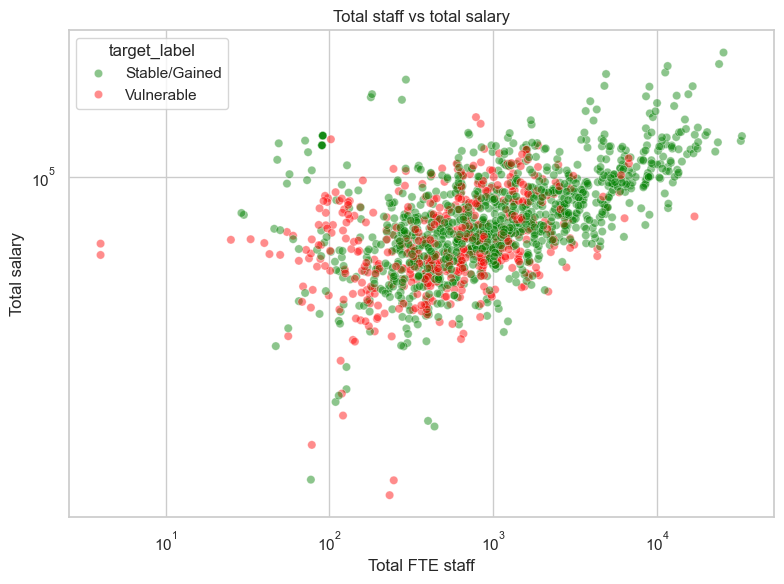

In [17]:
# 10) Scatter: total staff vs salary
plt.figure(figsize=(8, 6))
plot_df = master_panel_df.dropna(
    subset=["SFTETOTL", "SALTOTL", "TARGET_VULNERABLE_TOTAL"]
).copy()

plot_df["target_label"] = plot_df["TARGET_VULNERABLE_TOTAL"].astype(int).map(
    {0: "Stable/Gained", 1: "Vulnerable"}
)

# Clean numeric columns and create a categorical label for hue
plot_df = plot_df.copy()

plot_df["SFTETOTL"] = pd.to_numeric(plot_df["SFTETOTL"], errors="coerce")
plot_df["SALTOTL"] = pd.to_numeric(plot_df["SALTOTL"], errors="coerce")

plot_df = plot_df.dropna(subset=["SFTETOTL", "SALTOTL", "TARGET_VULNERABLE_TOTAL"]).copy()

plot_df["target_label"] = (
    plot_df["TARGET_VULNERABLE_TOTAL"].astype(int).map(
        {0: "Stable/Gained", 1: "Vulnerable"}
    )
)

sns.scatterplot(
    data=plot_df,
    x="SFTETOTL",
    y="SALTOTL",
    hue="target_label",
    alpha=0.45,
    palette=["green", "red"],
    hue_order=["Stable/Gained", "Vulnerable"],
)
plt.title("Total staff vs total salary")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Total FTE staff")
plt.ylabel("Total salary")
plt.tight_layout()
plt.show()